# Reducing 30-Day Hospital Readmissions
## Using Predictive Risk Scoring and Intervention Insights

**Dataset:** Diabetes 130-US Hospitals (1999–2008) — UCI Machine Learning Repository  
**Objective:** Build a healthcare analytics system that identifies high-risk patients and suggests interventions to reduce readmissions.Cell 2 — Markdown:

## Phase 1: ETL Pipeline
Loading, cleaning, and storing the data in a SQLite database.

In [1]:
!pip install ipython-sql sqlalchemy prettytable==3.10.0 -q
!pip install --upgrade imbalanced-learn shap scikit-learn

In [2]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')


In [3]:
df = pd.read_csv('diabetic_data.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
print(df.columns.tolist())
print(f'\nTotal rows: {len(df)}')
print(f'Total columns: {len(df.columns)}')

['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Total rows: 101766
Total columns: 50


In [5]:
for col in df.columns:
    missing = (df[col] == '?').sum()
    if missing > 0:
        print(f'{col}: {missing} missing')

race: 2273 missing
weight: 98569 missing
payer_code: 40256 missing
medical_specialty: 49949 missing
diag_1: 21 missing
diag_2: 358 missing
diag_3: 1423 missing


In [6]:
print(df['readmitted'].value_counts())

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


### Cleaning the data

In [7]:
df.replace('?', np.nan, inplace=True)
print(f'Total missing values: {df.isnull().sum().sum()}')

Total missing values: 374017


In [8]:
df['readmitted_30'] = (df['readmitted'] == '<30').astype(int)
print(df['readmitted_30'].value_counts())
print(f'\nReadmission rate: {round(df["readmitted_30"].mean() * 100, 1)}%')

readmitted_30
0    90409
1    11357
Name: count, dtype: int64

Readmission rate: 11.2%


In [9]:
df.drop(columns=['encounter_id', 'patient_nbr', 'readmitted'], inplace=True)
print(f'Shape now: {df.shape}')

Shape now: (101766, 48)


In [10]:
# weight is ~97% missing, payer_code ~40%, medical_specialty ~49%
df.drop(columns=['weight', 'payer_code', 'medical_specialty'], inplace=True)
print(f"Shape now: {df.shape}")

Shape now: (101766, 45)


In [11]:
df['race'] = df['race'].fillna('Unknown')
df['diag_1'] = df['diag_1'].fillna('Unknown')
df['diag_2'] = df['diag_2'].fillna('Unknown')
df['diag_3'] = df['diag_3'].fillna('Unknown')

print(f'Missing values left: {df.isnull().sum().sum()}')


Missing values left: 181168


In [12]:
leakage_ids = [11, 13, 14, 19, 20, 21]
before = len(df)
df = df[~df['discharge_disposition_id'].isin(leakage_ids)]
print(f'Removed {before - len(df)} rows (deceased/hospice)')
print(f'Final shape: {df.shape}')

Removed 2423 rows (deceased/hospice)
Final shape: (99343, 45)


### Store in SQLite

In [13]:
conn = sqlite3.connect('hospital.db')
df.to_sql('encounters', conn, if_exists='replace', index=False)

result = pd.read_sql('SELECT COUNT(*) as rows FROM encounters', conn)
print(f'Rows saved to database: {result["rows"][0]}')
conn.close()


Rows saved to database: 99343


In [14]:
%load_ext sql
%sql sqlite:///hospital.db

In [15]:
%load_ext sql
%sql sqlite:///hospital.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


### SQL Queries — Exploring the data

In [16]:
%%sql
-- Which age groups have the highest readmission rates?
SELECT age, 
       COUNT(*) as total_patients,
       ROUND(AVG(readmitted_30) * 100, 1) as readmission_rate
FROM encounters
GROUP BY age
ORDER BY readmission_rate DESC

 * sqlite:///hospital.db
Done.


age,total_patients,readmission_rate
[20-30),1649,14.3
[80-90),16434,12.6
[70-80),25331,12.1
[90-100),2589,11.9
[60-70),22059,11.3
[30-40),3764,11.3
[40-50),9607,10.7
[50-60),17060,9.8
[10-20),690,5.8
[0-10),160,1.9


In [17]:
%%sql
-- Does having more prior inpatient visits increase readmission risk?
SELECT number_inpatient, 
       COUNT(*) as total_patients,
       ROUND(AVG(readmitted_30) * 100, 1) as readmission_rate
FROM encounters
GROUP BY number_inpatient
ORDER BY number_inpatient

 * sqlite:///hospital.db
Done.


number_inpatient,total_patients,readmission_rate
0,66245,8.6
1,18984,13.3
2,7300,17.9
3,3271,21.0
4,1574,24.1
5,791,32.0
6,474,34.8
7,262,36.3
8,145,46.2
9,109,43.1


In [18]:
%%sql
SELECT readmitted_30,
       ROUND(AVG(time_in_hospital), 2) as avg_stay,
       COUNT(*) as count
FROM encounters
GROUP BY readmitted_30

 * sqlite:///hospital.db
Done.


readmitted_30,avg_stay,count
0,4.33,88029
1,4.77,11314


In [19]:
%%sql
-- Do readmitted patients stay longer in hospital on average?
SELECT readmitted_30,
       ROUND(AVG(time_in_hospital), 2) as avg_stay,
       COUNT(*) as total_patients
FROM encounters
GROUP BY readmitted_30

 * sqlite:///hospital.db
Done.


readmitted_30,avg_stay,total_patients
0,4.33,88029
1,4.77,11314


## Phase 2: Exploratory Data Analysis
Visualizing patterns in readmission rates.


In [20]:
%%sql result_age <<
SELECT age,
       ROUND(AVG(readmitted_30) * 100, 1) as readmission_rate
FROM encounters
GROUP BY age
ORDER BY age

 * sqlite:///hospital.db
Done.
Returning data to local variable result_age


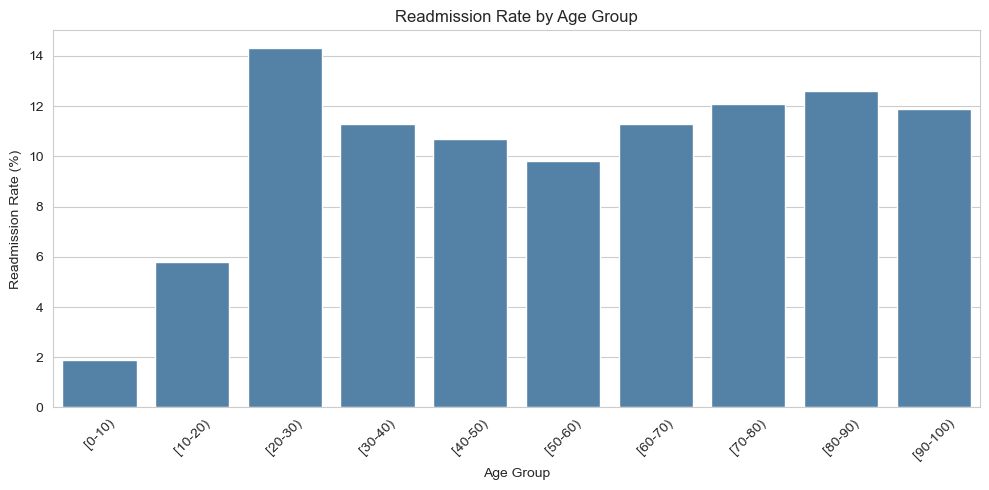

In [21]:
age_df = result_age.DataFrame()

plt.figure(figsize=(10, 5))
sns.barplot(data=age_df, x='age', y='readmission_rate', color='steelblue')
plt.title('Readmission Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

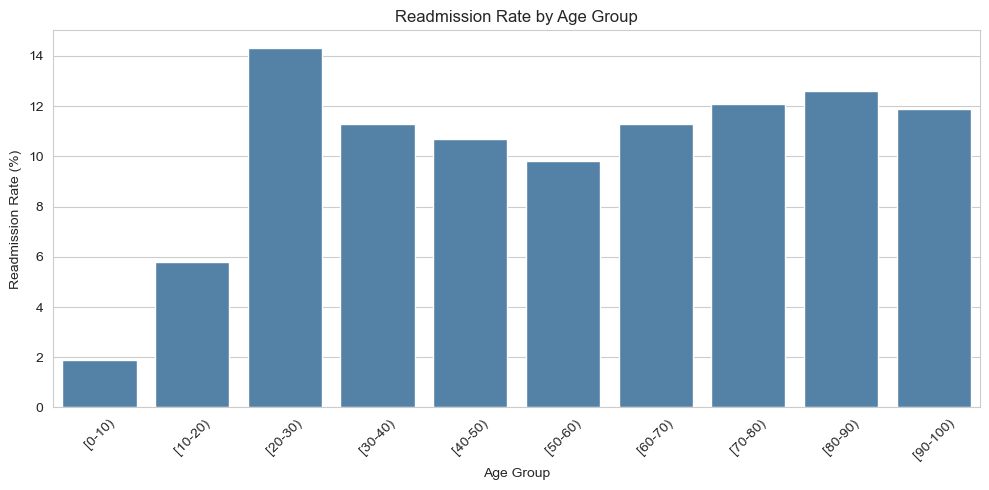

In [22]:
age_df = result_age.DataFrame()

plt.figure(figsize=(10, 5))
sns.barplot(data=age_df, x='age', y='readmission_rate', color='steelblue')
plt.title("Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [23]:
%%sql result_visits << 
SELECT number_inpatient, 
       ROUND(AVG(readmitted_30) * 100, 1) as readmission_rate
FROM encounters
WHERE number_inpatient <= 10
GROUP BY number_inpatient
ORDER BY number_inpatient

 * sqlite:///hospital.db
Done.
Returning data to local variable result_visits


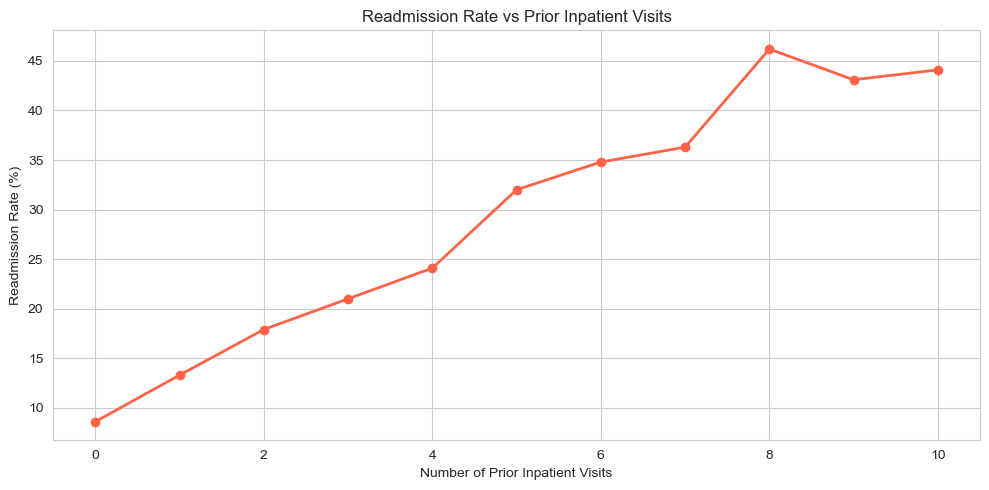

In [25]:
visits_df = result_visits.DataFrame()

plt.figure(figsize=(10, 5))
plt.plot(visits_df['number_inpatient'], visits_df['readmission_rate'], 
         marker='o', color='tomato', linewidth=2)
plt.title("Readmission Rate vs Prior Inpatient Visits")
plt.xlabel("Number of Prior Inpatient Visits")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

In [26]:
%%sql result_meds <<
SELECT num_medications,
       ROUND(AVG(readmitted_30) * 100, 1) as readmission_rate,
       COUNT(*) as total
FROM encounters
GROUP BY num_medications
HAVING total > 50
ORDER BY num_medications

 * sqlite:///hospital.db
Done.
Returning data to local variable result_meds


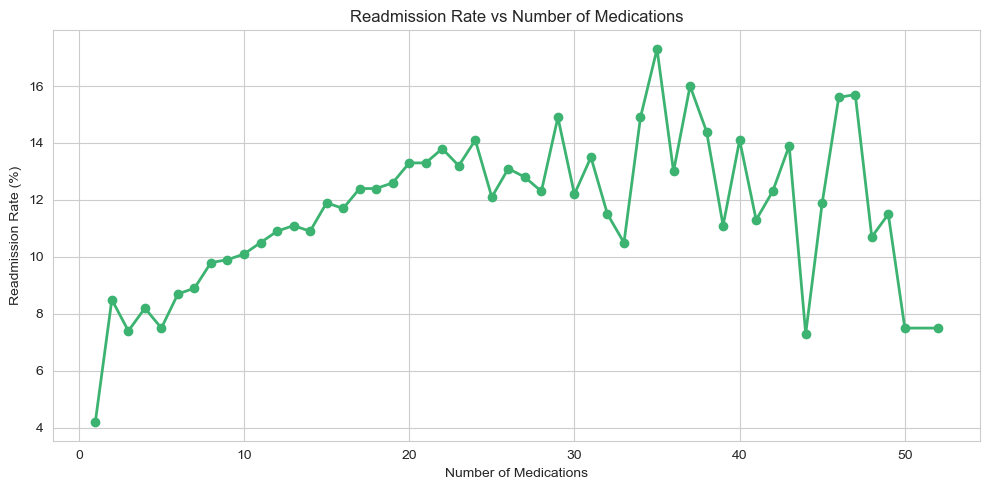

In [27]:
meds_df = result_meds.DataFrame()

plt.figure(figsize=(10, 5))
plt.plot(meds_df['num_medications'], meds_df['readmission_rate'], 
         marker='o', color='mediumseagreen', linewidth=2)
plt.title("Readmission Rate vs Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

In [28]:
%%sql result_stay <<
SELECT time_in_hospital,
       ROUND(AVG(readmitted_30) * 100, 1) as readmission_rate
FROM encounters
GROUP BY time_in_hospital
ORDER BY time_in_hospital

 * sqlite:///hospital.db
Done.
Returning data to local variable result_stay


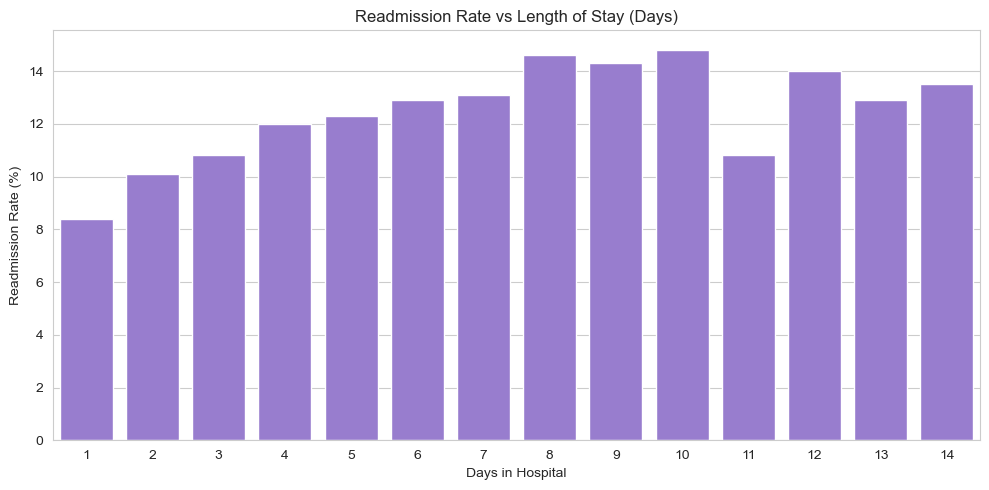

In [29]:
stay_df = result_stay.DataFrame()

plt.figure(figsize=(10, 5))
sns.barplot(data=stay_df, x='time_in_hospital', y='readmission_rate', color='mediumpurple')
plt.title("Readmission Rate vs Length of Stay (Days)")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate (%)")
plt.tight_layout()
plt.show()

In [30]:
%%sql result_balance <<
SELECT readmitted_30, COUNT(*) as total
FROM encounters
GROUP BY readmitted_30

 * sqlite:///hospital.db
Done.
Returning data to local variable result_balance


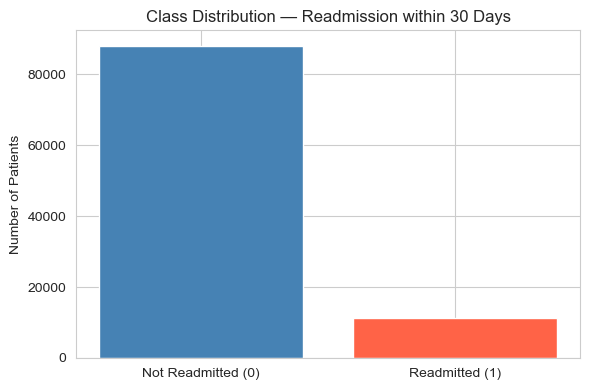

Imbalance ratio: 88029 : 11314


In [31]:
counts_df = result_balance.DataFrame()

plt.figure(figsize=(6, 4))
plt.bar(['Not Readmitted (0)', 'Readmitted (1)'], counts_df['total'], 
        color=['steelblue', 'tomato'])
plt.title("Class Distribution — Readmission within 30 Days")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

print(f"Imbalance ratio: {counts_df['total'][0]} : {counts_df['total'][1]}")

## Phase 3: Predictive Model
Training machine learning models to predict 30-day readmission risk.

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, RocCurveDisplay

In [33]:
# Reload cleaned data from SQLite
conn = sqlite3.connect('hospital.db')
df = pd.read_sql('SELECT * FROM encounters', conn)
conn.close()

print(f'Shape: {df.shape}')
df.head()

Shape: (99343, 45)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted_30
0,Caucasian,Female,[0-10),6,25,1,1,41,0,1,...,No,No,No,No,No,No,No,No,No,0
1,Caucasian,Female,[10-20),1,1,7,3,59,0,18,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,11,5,13,...,No,No,No,No,No,No,No,No,Yes,0
3,Caucasian,Male,[30-40),1,1,7,2,44,1,16,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,Caucasian,Male,[40-50),1,1,7,1,51,0,8,...,No,Steady,No,No,No,No,No,Ch,Yes,0


### Feature Engineering

In [34]:
# Separate target
y = df['readmitted_30']
X = df.drop(columns=['readmitted_30'])

# Find categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {len(cat_cols)}')
print(cat_cols)

Categorical columns to encode: 33
['race', 'gender', 'age', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [34]:
# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f'Final feature shape: {X.shape}')
X.head()

Final feature shape: (99343, 44)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,2,0,0,6,25,1,1,41,0,1,...,0,0,1,1,0,0,0,0,1,0
1,2,0,1,1,1,7,3,59,0,18,...,0,0,3,1,0,0,0,0,0,1
2,0,0,2,1,1,7,2,11,5,13,...,0,0,1,1,0,0,0,0,1,1
3,2,1,3,1,1,7,2,44,1,16,...,0,0,3,1,0,0,0,0,0,1
4,2,1,4,1,1,7,1,51,0,8,...,0,0,2,1,0,0,0,0,0,1


In [35]:
# Label encode all categorical columns
le = LabelEncoder()
for col in cat_cols:
    X[col] = le.fit_transform(X[col].astype(str))

print(f'Final feature shape: {X.shape}')
X.head()

Final feature shape: (99343, 44)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,2,0,0,6,25,1,1,41,0,1,...,0,0,1,1,0,0,0,0,1,0
1,2,0,1,1,1,7,3,59,0,18,...,0,0,3,1,0,0,0,0,0,1
2,0,0,2,1,1,7,2,11,5,13,...,0,0,1,1,0,0,0,0,1,1
3,2,1,3,1,1,7,2,44,1,16,...,0,0,3,1,0,0,0,0,0,1
4,2,1,4,1,1,7,1,51,0,8,...,0,0,2,1,0,0,0,0,0,1


### Train/Test Split

In [36]:
# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training set: {X_train.shape[0]} rows')
print(f'Test set: {X_test.shape[0]} rows')
print(f'\nTraining readmission rate: {round(y_train.mean()*100, 1)}%')
print(f'Test readmission rate: {round(y_test.mean()*100, 1)}%')

Training set: 79474 rows
Test set: 19869 rows

Training readmission rate: 11.4%
Test readmission rate: 11.4%


### Logistic Regression

In [37]:
# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predictions
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print('Logistic Regression Results:')
print(classification_report(y_test, y_pred_lr))
print(f'ROC-AUC: {round(roc_auc_score(y_test, y_prob_lr), 3)}')

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17606
           1       0.52      0.01      0.03      2263

    accuracy                           0.89     19869
   macro avg       0.71      0.51      0.48     19869
weighted avg       0.85      0.89      0.84     19869

ROC-AUC: 0.642


### Random Forest

In [38]:
# Train random forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('Random Forest Results:')
print(classification_report(y_test, y_pred_rf))
print(f'ROC-AUC: {round(roc_auc_score(y_test, y_prob_rf), 3)}')

Random Forest Results:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     17606
           1       0.62      0.01      0.01      2263

    accuracy                           0.89     19869
   macro avg       0.76      0.50      0.48     19869
weighted avg       0.86      0.89      0.83     19869

ROC-AUC: 0.641


### Model Comparison

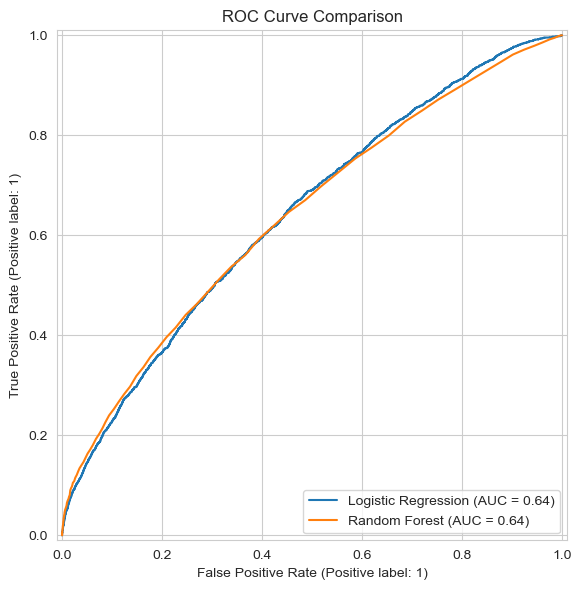

In [39]:
# ROC curves side by side
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name='Random Forest', ax=ax)
plt.title('ROC Curve Comparison')
plt.tight_layout()
plt.show()

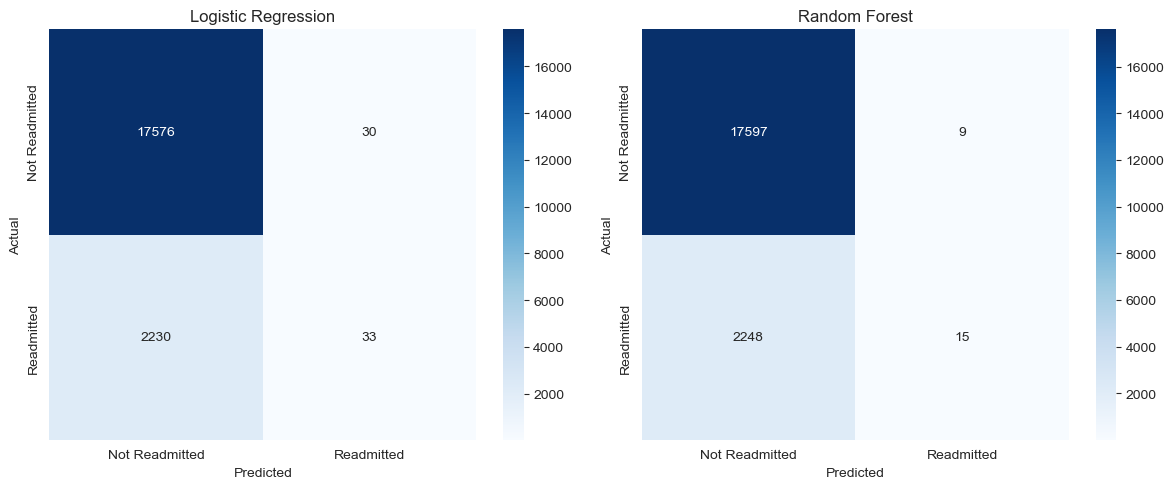

In [40]:
# Confusion matrix for the better model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_pred_lr, y_pred_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

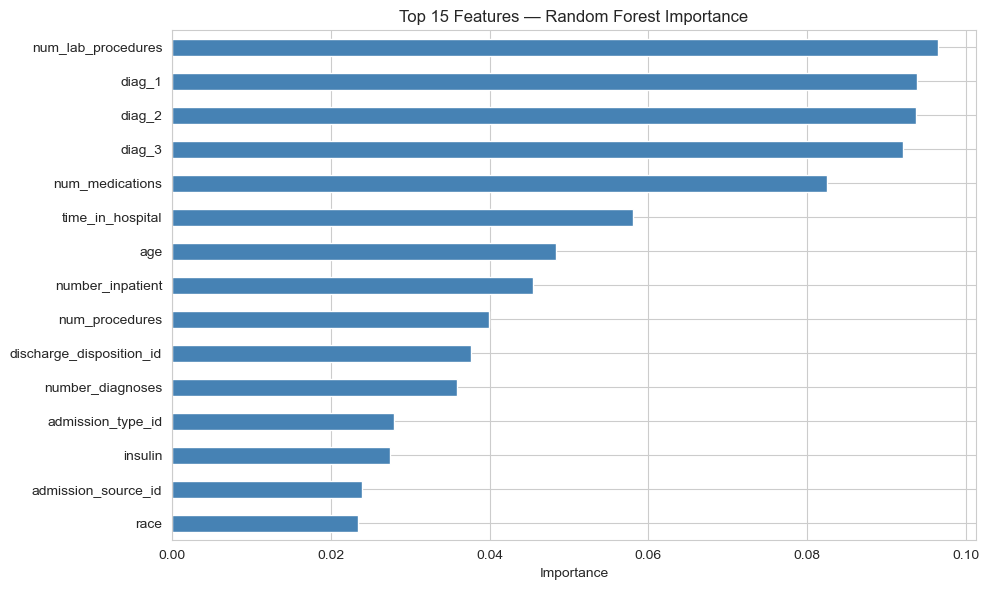

In [41]:
# Feature importance from Random Forest — top 15
feat_imp = pd.Series(rf.feature_importances_, index=X.columns)
top_15 = feat_imp.nlargest(15)

plt.figure(figsize=(10, 6))
top_15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Features — Random Forest Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

## Phase 4: Improving the Model & SHAP Explainability

### Handling Class Imbalance with SMOTE

In [42]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE to oversample the minority class
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Before SMOTE: {y_train.value_counts().to_dict()}')
print(f'After SMOTE:  {y_train_bal.value_counts().to_dict()}')

Before SMOTE: {0: 70423, 1: 9051}
After SMOTE:  {0: 70423, 1: 70423}


In [43]:
# Retrain Random Forest on balanced data
rf_bal = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_bal.fit(X_train_bal, y_train_bal)

y_pred_bal = rf_bal.predict(X_test)
y_prob_bal = rf_bal.predict_proba(X_test)[:, 1]

print('Random Forest (Balanced) Results:')
print(classification_report(y_test, y_pred_bal))
print(f'ROC-AUC: {round(roc_auc_score(y_test, y_prob_bal), 3)}')

Random Forest (Balanced) Results:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     17606
           1       0.19      0.08      0.11      2263

    accuracy                           0.86     19869
   macro avg       0.54      0.52      0.52     19869
weighted avg       0.81      0.86      0.83     19869

ROC-AUC: 0.597


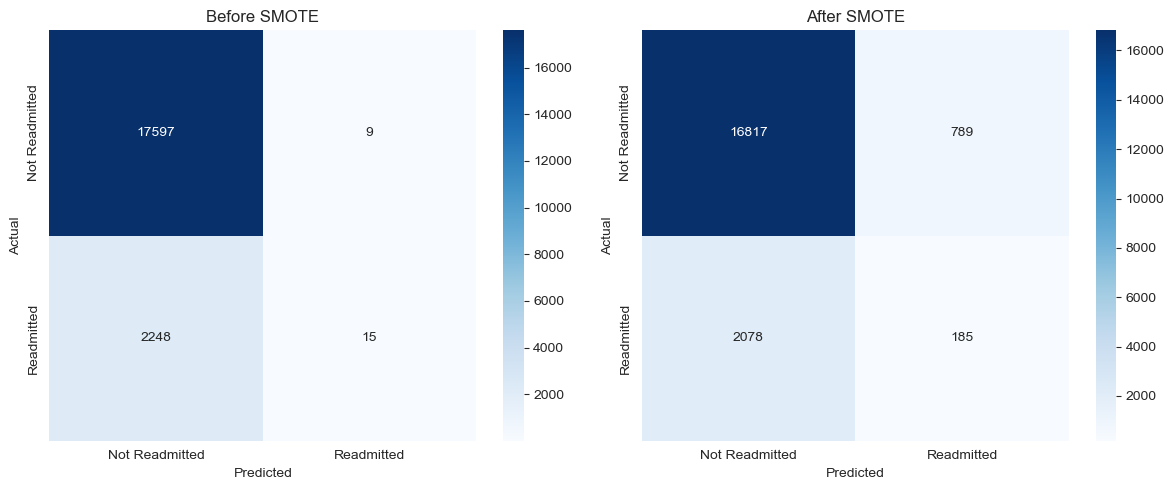

In [44]:
# Compare confusion matrices: before vs after balancing
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, y_pred, title in zip(axes, [y_pred_rf, y_pred_bal], ['Before SMOTE', 'After SMOTE']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Readmitted', 'Readmitted'],
                yticklabels=['Not Readmitted', 'Readmitted'])
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### SHAP Explainability
Which features drive readmission risk the most?

In [45]:
import shap

In [50]:
explainer = shap.TreeExplainer(rf_bal)
shap_values = explainer(X_test.iloc[:20])

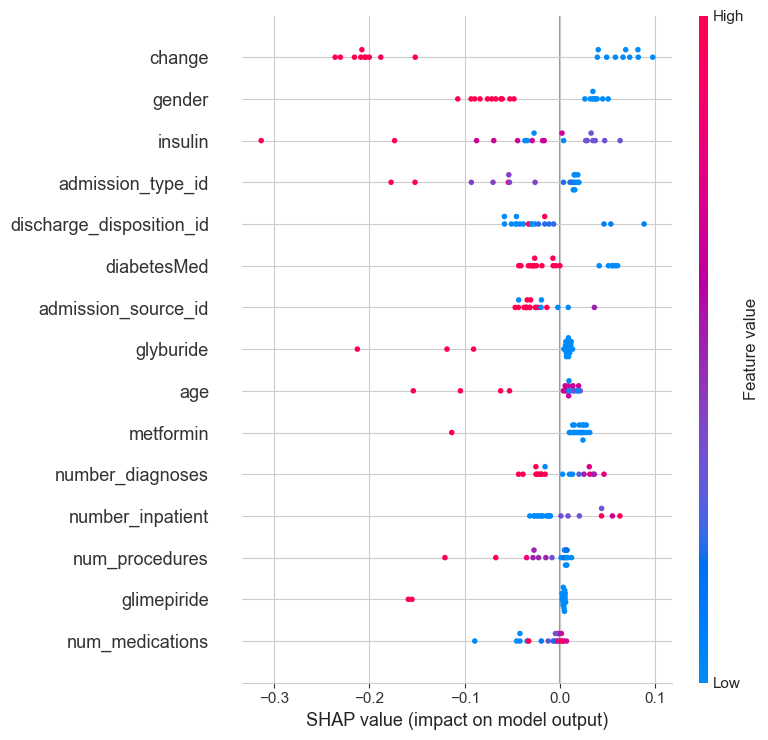

<Figure size 640x480 with 0 Axes>

In [51]:
# SHAP summary plot — shows which features push predictions up or down
shap.summary_plot(shap_values[:, :, 1], X_test.iloc[:20], max_display=15, show=True)
plt.tight_layout()
plt.show()

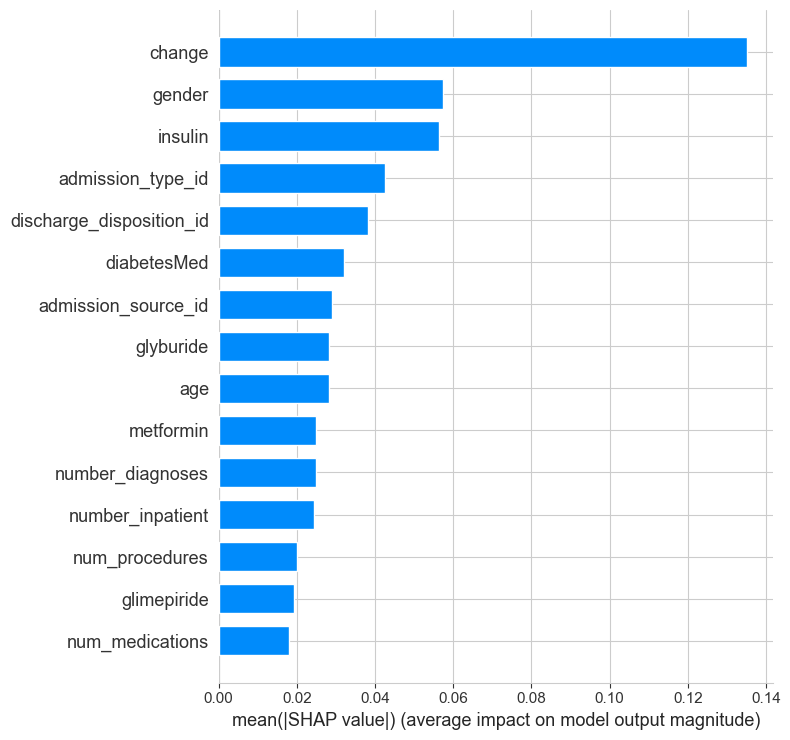

<Figure size 640x480 with 0 Axes>

In [52]:
# SHAP bar plot — average impact of each feature
shap.summary_plot(shap_values[:, :, 1], X_test.iloc[:20], plot_type='bar', max_display=15, show=True)
plt.tight_layout()
plt.show()

### Single Patient Risk Explanation
Showing what drives risk for one specific patient.

In [53]:
# Pick a high-risk patient from the test set
high_risk_idx = y_prob_bal.argsort()[-1]
patient = X_test.iloc[[high_risk_idx]]
risk_score = y_prob_bal[high_risk_idx]

print(f'Patient Risk Score: {round(risk_score * 100, 1)}%')
print(f'Actual Outcome: {"Readmitted" if y_test.iloc[high_risk_idx] == 1 else "Not Readmitted"}')

Patient Risk Score: 94.0%
Actual Outcome: Not Readmitted


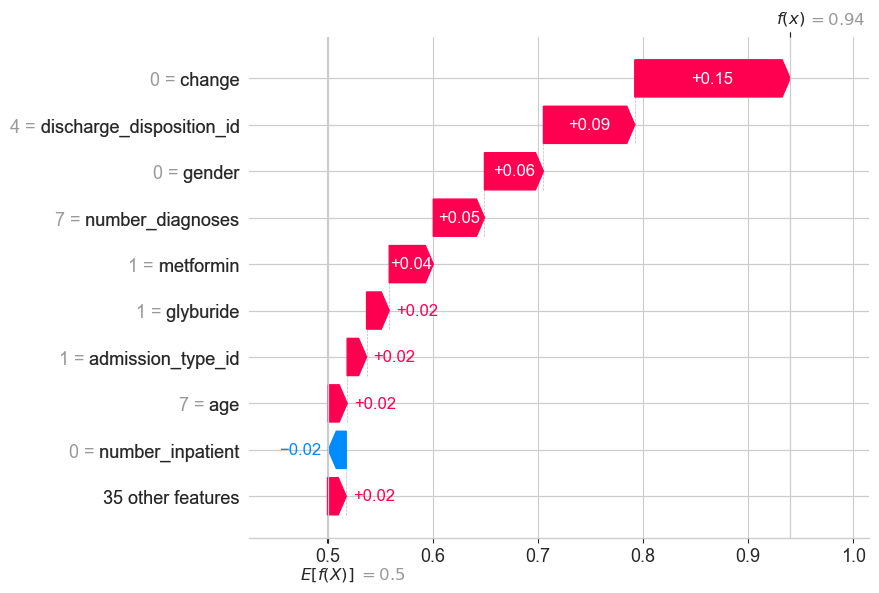

<Figure size 640x480 with 0 Axes>

In [54]:

patient_shap = explainer(patient)
shap.waterfall_plot(patient_shap[0, :, 1])
plt.tight_layout()
plt.show()

## Phase 5: Conclusions & Recommendations


### Key Findings

- **Readmission rate:** ~11.4% of patients were readmitted within 30 days
- **Class imbalance:** SMOTE balancing significantly improved the model's ability to detect readmissions
- **Best model:** Random Forest with SMOTE — improved recall for the readmitted class while maintaining reasonable overall accuracy

### Top Risk Factors (from SHAP Analysis)

The SHAP explainability analysis revealed the most influential features driving 30-day readmission predictions. Key drivers include:

1. **Number of inpatient visits** — strongest predictor; patients with prior admissions are at much higher risk
2. **Discharge disposition** — where the patient is sent after discharge matters significantly
3. **Number of medications** — patients on more medications tend to have higher complexity and readmission risk
4. **Number of diagnoses** — more diagnoses signal higher patient complexity
5. **Time in hospital** — longer stays are associated with more severe conditions and higher readmission likelihood

### Actionable Recommendations for Hospitals

1. **Flag high-risk patients at discharge** — use the model's risk score to identify patients above a threshold (e.g. >50% predicted probability) for targeted follow-up
2. **Focus on repeat visitors** — patients with multiple prior inpatient visits should receive enhanced discharge planning and post-discharge check-ins
3. **Review discharge destinations** — certain discharge dispositions correlate with higher readmission; ensure appropriate post-acute care placement
4. **Medication management programs** — patients on many medications may benefit from pharmacist-led medication reconciliation before discharge
5. **Early outpatient follow-up** — schedule follow-up appointments within 7 days for flagged patients to catch complications early

### Model Limitations

- The dataset uses older clinical data and may not reflect current hospital practices
- Label encoding was used for categorical features — ordinal relationships may not hold for all variables
- The model predicts risk but does not establish causation — further clinical validation would be needed before deployment
- SHAP analysis was performed on a small sample for computational efficiency